In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_circles, make_blobs, make_moons
from sklearn.preprocessing import MinMaxScaler
np.random.seed(42)

# $k$-means clustering

In [21]:

# Extracted points from the four clusters in the image
points = [
    (1.2, 3.5), (1.5, 3.4), (1.3, 3.8), (1.6, 4.5), (1.4, 3.1), (1.3, 4.6), (1.8, 3.3), (2.1, 3.8), (2.5, 4.2), (2.9, 5.2), (3.1, 4.8), (3.2, 5.5), (3.3, 4.4), (3.6, 5.1), (3.8, 4.1), (4.1, 4.9), (4.5, 5.1), (3.6, 3.6), (2.6, 3.4), (3.8, 1.2), (4.1, 1.8), (4.4, 2.2), (4.8, 2.0), (5.1, 1.6), (5.5, 1.5), (6.1, 1.4), (4.6, 1.1), (4.2, 0.8), (6.0, 3.2), (6.4, 3.4), (6.6, 3.1), (7.1, 3.3), (7.2, 3.9)
]

X = np.array(points)

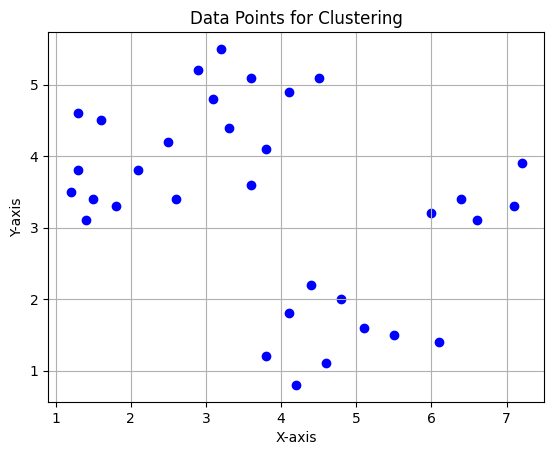

In [22]:
plt.scatter(X[:, 0], X[:, 1], c='blue', marker='o')
plt.title('Data Points for Clustering')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid()
plt.show()

## Manual initialization of centroids

### A.

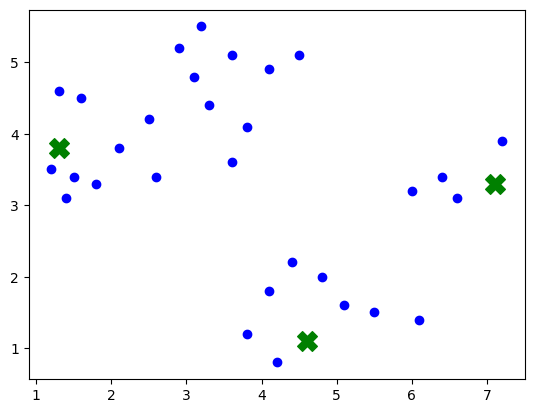

In [23]:
init_1 = np.array([[1.3, 3.8], [4.6, 1.1], [7.1, 3.3]])#

plt.scatter(X[:, 0], X[:, 1], c='blue', marker='o', label='Data Points')
plt.scatter(init_1[:, 0], init_1[:, 1], c='green', marker='X', s=200, label='Initial Centroids 1')

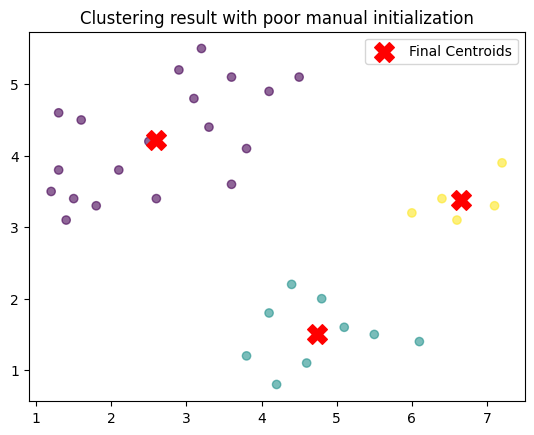

In [24]:
km = KMeans(n_clusters=3, init=init_1, n_init=1, max_iter=300)
km.fit(X)

# Visualize the result
plt.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', alpha=0.6)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Final Centroids')
plt.title("Clustering result with poor manual initialization")
plt.legend()
plt.show()

In [25]:
# calculate cost function (inertia) for the clustering result
inertia = km.inertia_
print(f"Inertia (Cost Function Value): {inertia}")

Inertia (Cost Function Value): 37.545730994152045


### B.

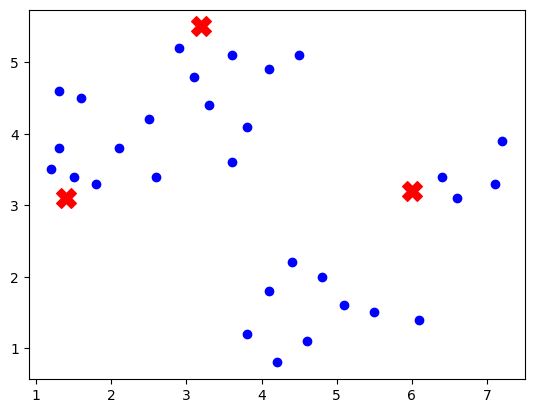

In [26]:
init_2 = np.array([[1.4, 3.1], [3.2, 5.5], [6.0, 3.2]])

plt.scatter(X[:, 0], X[:, 1], c='blue', marker='o', label='Data Points')
plt.scatter(init_2[:, 0], init_2[:, 1], c='red', marker='X', s=200, label='Initial Centroids 2')

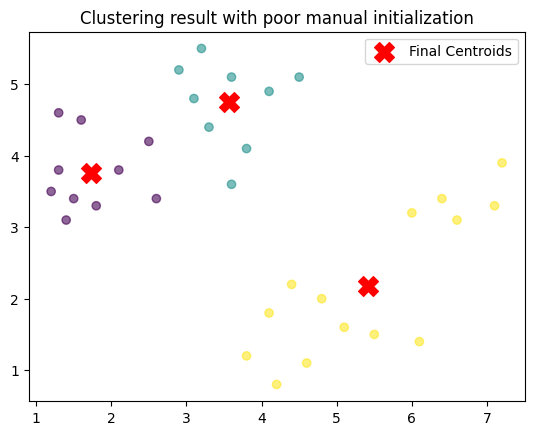

In [27]:
km = KMeans(n_clusters=3, init=init_2, n_init=1, max_iter=300)
km.fit(X)

# Visualize the result
plt.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', alpha=0.6)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Final Centroids')
plt.title("Clustering result with poor manual initialization")
plt.legend()
plt.show()

In [28]:
inertia = km.inertia_
print(f"Inertia (Cost Function Value): {inertia}")

Inertia (Cost Function Value): 40.13436507936507


### C.

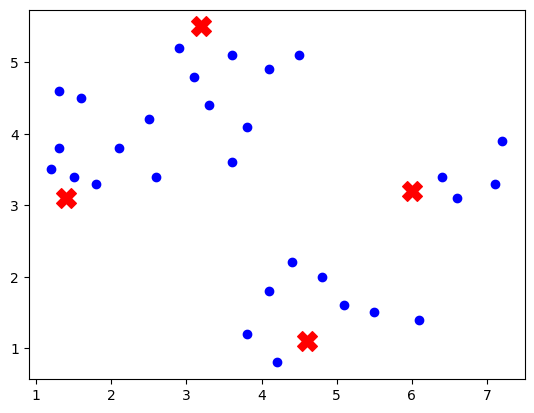

In [31]:
init_3 = np.array([[1.4, 3.1], [3.2, 5.5], [6.0, 3.2], [4.6, 1.1]])

plt.scatter(X[:, 0], X[:, 1], c='blue', marker='o', label='Data Points')
plt.scatter(init_3[:, 0], init_3[:, 1], c='red', marker='X', s=200, label='Initial Centroids 3')

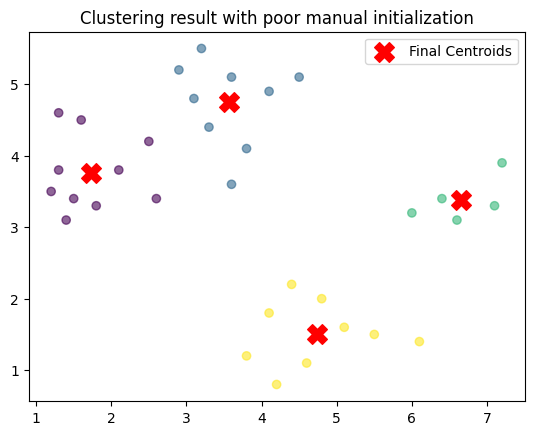

In [32]:
km = KMeans(n_clusters=4, init=init_3, n_init=1, max_iter=300)
km.fit(X)

# Visualize the result
plt.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', alpha=0.6)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Final Centroids')
plt.title("Clustering result with poor manual initialization")
plt.legend()
plt.show()

In [33]:
inertia = km.inertia_
print(f"Inertia (Cost Function Value): {inertia}")

Inertia (Cost Function Value): 16.976111111111113


## K-Means++ initialization

In [36]:
# Initialize K-Means (default uses k-means++ initialization)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=40)

# Fit the model
kmeans.fit(X)

# Get the cluster assignments and the final centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

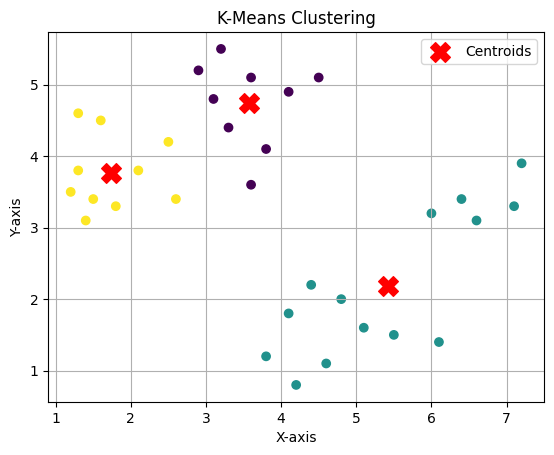

In [37]:
# Visualize the clusters and centroids
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid()
plt.show()

## Different number of clusters

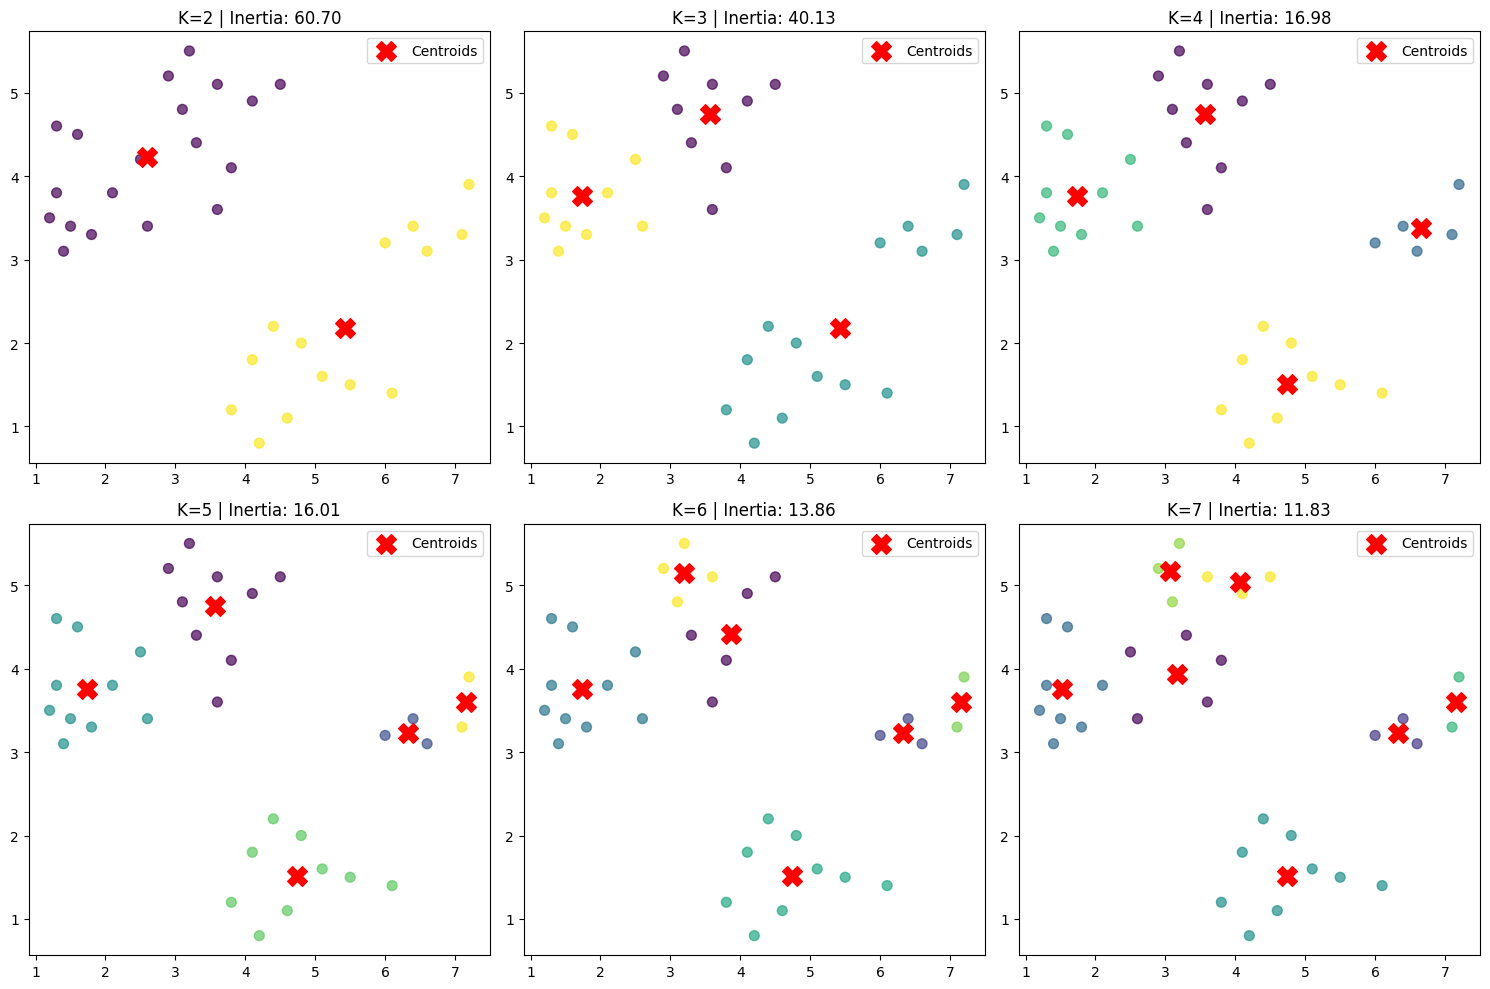

In [39]:
k_values = [2, 3, 4, 5, 6, 7]
inertias = []

plt.figure(figsize=(15, 10))

for i, k in enumerate(k_values):
    # k-means++ is the default in sklearn, but we'll be explicit
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

    plt.subplot(2, 3, i+1)
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', s=50, alpha=0.7)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker='X', s=200, c='red', label='Centroids')
    plt.title(f"K={k} | Inertia: {kmeans.inertia_:.2f}")
    plt.legend()

plt.tight_layout()
plt.show()

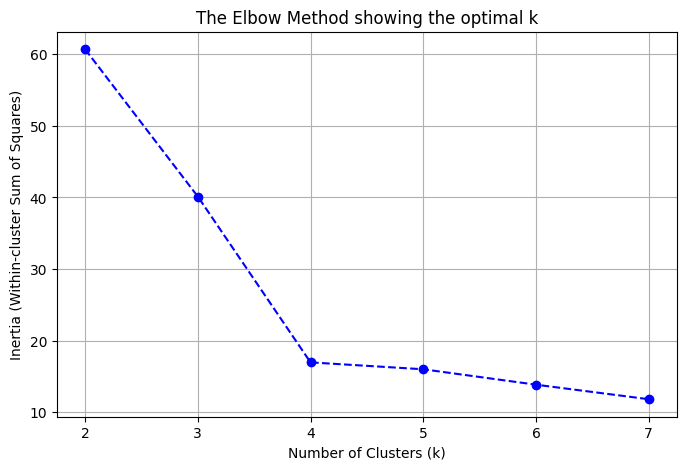

In [40]:
# elbow method plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('The Elbow Method showing the optimal k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

## Where $k$-means succeeds and fails

$k$-means assumes that clusters are spherical and of similar size. It can struggle with:
- Non-spherical clusters (e.g., elongated or donut-shaped)
- Clusters of different sizes and densities
- Outliers that can skew the centroids

In [75]:
# donut-shaped data
X_circles, _ = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)
X_circles = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_circles)

# parallel lines
line1 = np.column_stack((np.linspace(0, 10, 200), np.zeros(200)))
line2 = np.column_stack((np.linspace(0, 10, 200), np.ones(200) * 2))
X_lines = np.vstack((line1, line2))
X_lines = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_lines)


# differently sized clusters
normal_data = np.random.normal(loc=10, scale=3, size=(50, 2))
anomaly_data = np.random.normal(loc=15, scale=0.5, size=(20, 2))
X_sizes = np.vstack((normal_data, anomaly_data))
X_sizes = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_sizes)

# moons
X_moon, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
X_moon = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_moon)

# outliers
X_outlier, _ = make_blobs(n_samples=50, centers=1, cluster_std=0.5, random_state=42)
X_outlier = np.vstack([X_outlier, [10, 10]]) # Add a far outlier
X_outlier = MinMaxScaler(feature_range=(0, 2)).fit_transform(X_outlier)

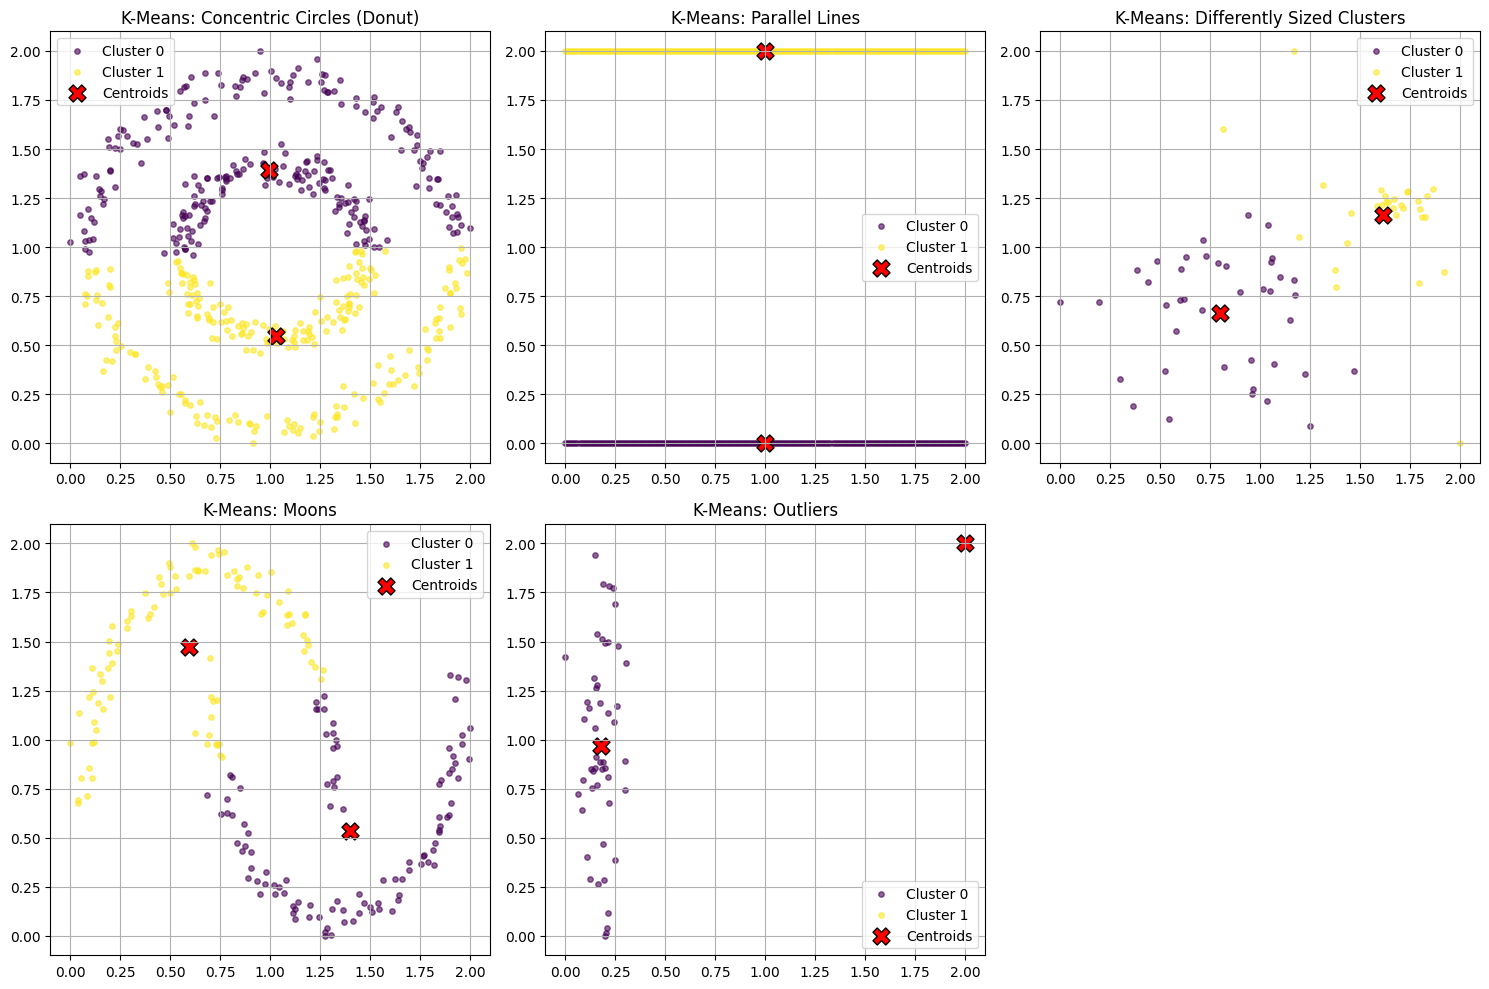

In [76]:
scenarios = [
    ("Concentric Circles (Donut)", X_circles, 2),
    ("Parallel Lines", X_lines, 2),
    ("Differently Sized Clusters", X_sizes, 2),
    ("Moons", X_moon, 2),
    ("Outliers", X_outlier, 2)
]

plt.figure(figsize=(15, 10))

for i, (name, X, k) in enumerate(scenarios):
    # n_init='auto' handles modern scikit-learn defaults (often 10)
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    y_pred = kmeans.fit_predict(X)

    plt.subplot(2, 3, i + 1)

    # Use different colors for predicted clusters
    colors = plt.cm.viridis(np.linspace(0, 1, k))
    for label, color in zip(range(k), colors):
        plt.scatter(X[y_pred == label, 0], X[y_pred == label, 1], color=color, alpha=0.6, s=15, label=f'Cluster {label}')

    # Plot final centroids
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=150, c='red', edgecolor='black', label='Centroids')

    plt.title(f"K-Means: {name}")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()